#Decision Boundaries Experiment

In this notebook, we will test our models, including a logistic regression classifier, support vector machine, and a shallow multilayer perceptron.

We will test each of these models on three datasets imported from scikit-learn: including `make_blobs`, `make_moons`, and `make_circles`.

let's start by importing the functions we will need.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles
from sklearn.datasets import make_moons
import os
import requests

Now, let's define a function that will allow us to import our classes or helper functions from GitHub, and we will go ahead and import our models and decision boundary function.

In [2]:
def import_from_github(raw_url, filename, folder=""):
    """
    Downloads a file from a GitHub raw URL and saves it locally.

    Parameters
    ----------
    raw_url : str
        The raw GitHub URL to the file.

    filename : str
        Name you want to save the file as.

    folder : str, optional
        Folder to save the file in. Created if it doesn't exist.

    Returns
    -------
    str
        Full path to the downloaded file.
    """

    # Create folder if needed
    if folder:
        os.makedirs(folder, exist_ok=True)
        filepath = os.path.join(folder, filename)
    else:
        filepath = filename

    # Download file
    response = requests.get(raw_url)
    response.raise_for_status()

    # Save file
    with open(filepath, "wb") as f:
        f.write(response.content)

    print(f"Saved to {filepath}")

    return filepath

import_from_github("https://raw.githubusercontent.com/NK-MATRIX/Classical-Machine-Learning-From-Scratch/refs/heads/main/helper%20functions/plot_decision_boundary.py", filename="plot_decision_boundary.py", folder="helper_functions")
import_from_github("https://raw.githubusercontent.com/NK-MATRIX/Classical-Machine-Learning-From-Scratch/refs/heads/main/models/Logistic_Regression_Class.py", filename="logistic_regression_class.py", folder="models")
import_from_github("https://raw.githubusercontent.com/NK-MATRIX/Classical-Machine-Learning-From-Scratch/refs/heads/main/models/Neural_Network_Class.py", filename="neural_network_class.py", folder="models")
import_from_github("https://raw.githubusercontent.com/NK-MATRIX/Classical-Machine-Learning-From-Scratch/refs/heads/main/models/Support_Vector_Machine_Class.py", filename="support_vector_machine_class.py", folder="models")

Saved to helper_functions/plot_decision_boundary.py
Saved to models/logistic_regression_class.py
Saved to models/neural_network_class.py
Saved to models/support_vector_machine_class.py


'models/support_vector_machine_class.py'

Let's also import our decision boundary plotting function here, which will be used in every test.

In [3]:
from helper_functions.plot_decision_boundary import plot_decision_boundary

## Make_Blobs

Now let's move onto our first dataset: `make_blobs`.

We will train a logistic regression classifier, support vector machine, and neural network, and display their accuracy along with the corresponding decision boundary.

Let's create the blobs and visualize them.

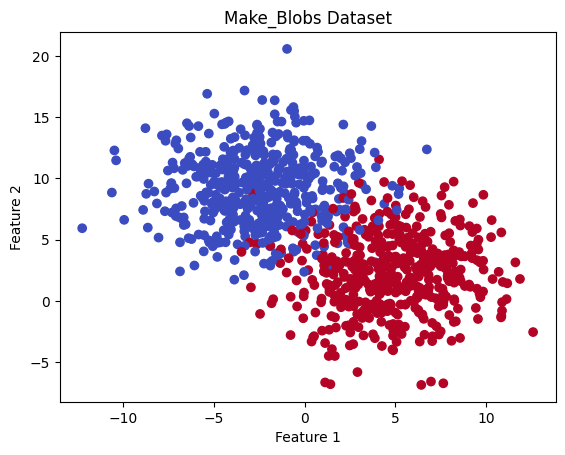

In [4]:
X_blobs, Y_blobs = make_blobs(n_samples=1000,
                  centers=2,
                  n_features=2,
                  random_state=42,
                  cluster_std=3)

plt.figure(figsize=(6.4, 4.8))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=Y_blobs, cmap=plt.cm.coolwarm)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make_Blobs Dataset")
plt.show();

### Logistic Regression on Blobs
let's create a logistic regression model, train it, and plot it's decision boundary

Through experimentation, I found these hyperparameters to converge well on this dataset:
* lr = 0.01
* eps=10e-5

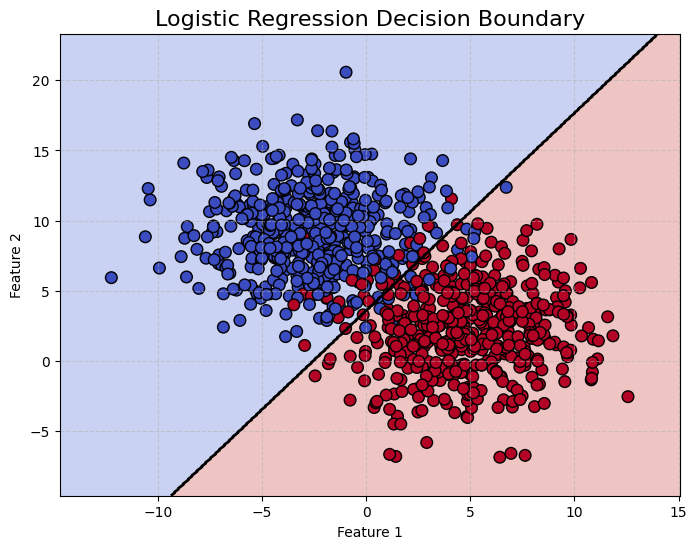


Accuracy: 95.10%


In [5]:
from models.logistic_regression_class import Logistic_Regression

lr_blobs = Logistic_Regression(eps=10e-5)
lr_blobs.fit(X_blobs, Y_blobs, lr=0.01)
plot_decision_boundary(lr_blobs, X_blobs, Y_blobs, figsize=(8, 6), resolution=500)
print(f"\nAccuracy: {np.mean(lr_blobs.predict(X_blobs)==Y_blobs)*100:.2f}%")

### Support Vector Machine on Blobs
Now let's train our support vector machine on the blob dataset, and again show our accuracy and decision boundary.

Through experimentation, I found these hyperparameters to converge well on this dataset:
* sigma = 1
* C = 0.90
* tol = 1e-3
* max_passes = 10

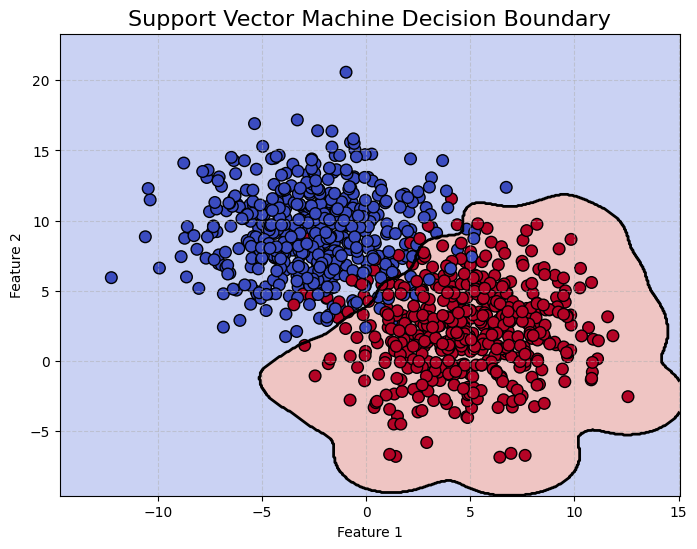


Accuracy: 95.50%


In [25]:
from models.support_vector_machine_class import SVM

svm_blobs = SVM(sigma=1)
svm_blobs.fit(X_blobs, Y_blobs, C=0.90, tol=1e-3, max_passes=10)
plot_decision_boundary(svm_blobs, X_blobs, Y_blobs, figsize=(8, 6), resolution=500)
svm_blobs_pred = svm_blobs.predict(X_blobs, Y_blobs, X_blobs)

# Our svm makes the Y=0 class to y=-1. let's fix this after training
Y_blobs[Y_blobs==-1] = 0

print(f"\nAccuracy: {np.mean(svm_blobs_pred==Y_blobs)*100:.2f}%")

### Neural Network on Blobs
finally, we will test our neural network implementation on the blobs dataset, again printing the accuracy and displaying the decision boundary.

Through experimentation, I found these hyperparameters to converge well on this dataset:
* epochs = 1250
* lr = 0.35
* update_lr = True (activates our learning rate scheduler)

epoch: 0: Loss; 0.7585279748214139, Training Accuracy; 0.5
epoch: 125: Loss; 0.47537620681587944, Training Accuracy; 0.94
epoch: 250: Loss; 0.27393079520389724, Training Accuracy; 0.942
epoch: 375: Loss; 0.23429612401439517, Training Accuracy; 0.943
epoch: 500: Loss; 0.21208322621157602, Training Accuracy; 0.943
epoch: 625: Loss; 0.2045849061367976, Training Accuracy; 0.944
epoch: 750: Loss; 0.19857033793373738, Training Accuracy; 0.945
epoch: 875: Loss; 0.1959743075863115, Training Accuracy; 0.945
epoch: 1000: Loss; 0.19359022555996067, Training Accuracy; 0.945
epoch: 1125: Loss; 0.19246525144451657, Training Accuracy; 0.945


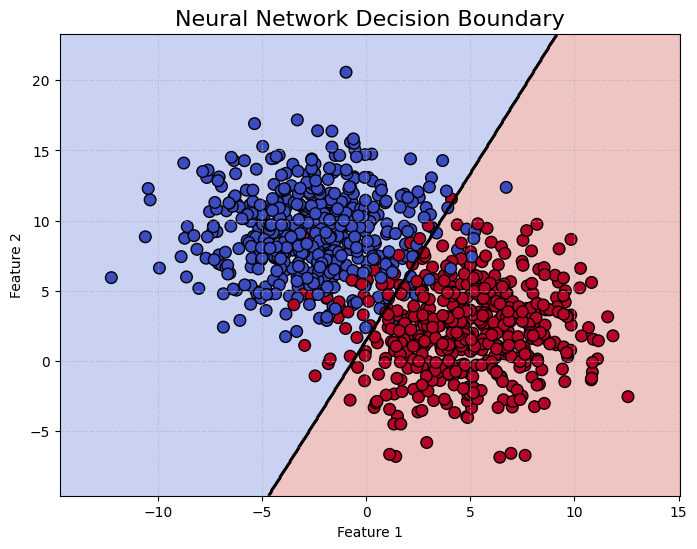


Accuracy: 94.50%


In [7]:
from models.neural_network_class import NeuralNetwork

nn_blobs = NeuralNetwork()
# Our neural network class expects our data to be in the shape of (n, m)
# update_lr activates a crude learning rate scheduler, just dividing it by two periodically.
nn_blobs.fit(X_blobs.T, Y_blobs.T, epochs=1250, lr=0.35, update_lr=True)
plot_decision_boundary(nn_blobs, X_blobs, Y_blobs, figsize=(8, 6), resolution=500)
print(f"\nAccuracy: {np.mean(nn_blobs.predict(X_blobs.T)==Y_blobs)*100:.2f}%")


### Blobs Summary
Overall, the `make_blobs` dataset is one that can be separated nicely with a linear decision boundary, as seen by the logistic regression classifier and neural network. The support vector machine worked well when separating it, however its decision boundary is much more serrated, meaning that the logistic regression classifier had arguably the best performance on this dataset.

Let's move onto the `make_moons` dataset.

##Make_Moons

In this section, we will implement our logistic regression classifier, support vector machine, and neural network on our seconds dataset, `make_moons`, from scikit-learn.

Let's start by creating the dataset and visualizing it.

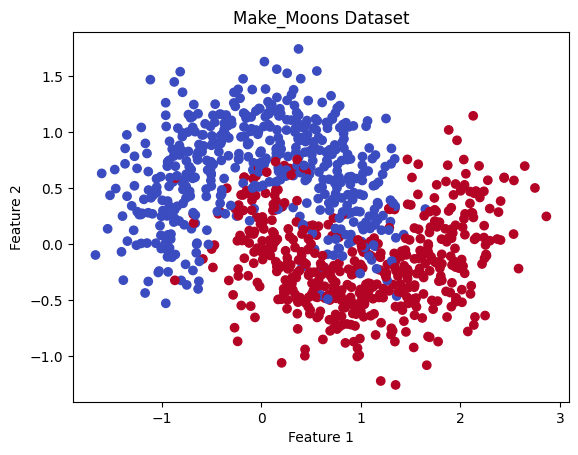

In [37]:
X_moons, Y_moons = make_moons(n_samples=1000,
                              noise=0.30,
                              random_state=42)

plt.figure(figsize=(6.4, 4.8))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=Y_moons, cmap=plt.cm.coolwarm)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make_Moons Dataset")
plt.show();

###Logistic Regression on Moons
Again, we will start by implementing our logistic regression classifier on our dataset, analyzing it by printing the accuracy and visualizing the decision boundary.

Through experimentation, I found these hyperparameters to converge well on this dataset:
* lr = 0.01
* eps = 10e-5

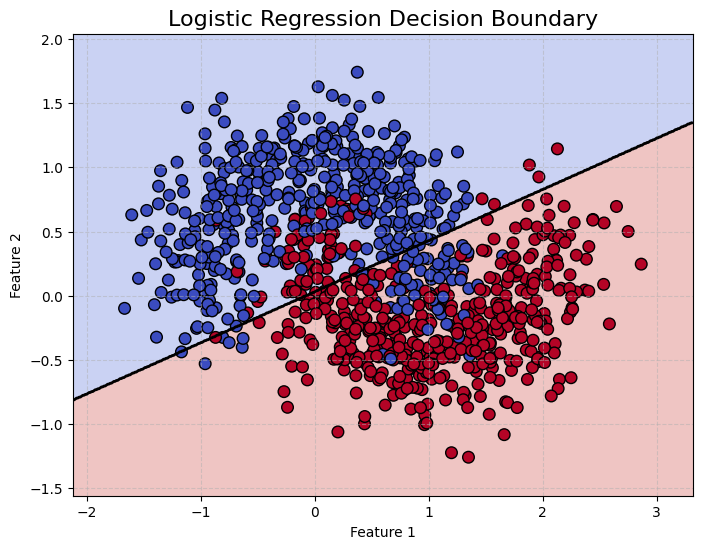


Accuracy: 85.10%


In [38]:
from models.logistic_regression_class import Logistic_Regression

lr_moons = Logistic_Regression(eps=10e-5)
lr_moons.fit(X_moons, Y_moons, lr=0.01)
plot_decision_boundary(lr_moons, X_moons, Y_moons, figsize=(8, 6), resolution=500)
print(f"\nAccuracy: {np.mean(lr_moons.predict(X_moons)==Y_moons)*100:.2f}%")

###Support Vector Machine on Moons
Next, we will implement our support vector machine, this time on our `make_moons` dataset, analyzing it by plotting the decision boundary and printing the accuracy, as seen before.

Through experimentation, I found these hyperparameters to converge well on this dataset:
* sigma = 1
* C = 2.0
* tol = 10e-3
* max_passes = 10

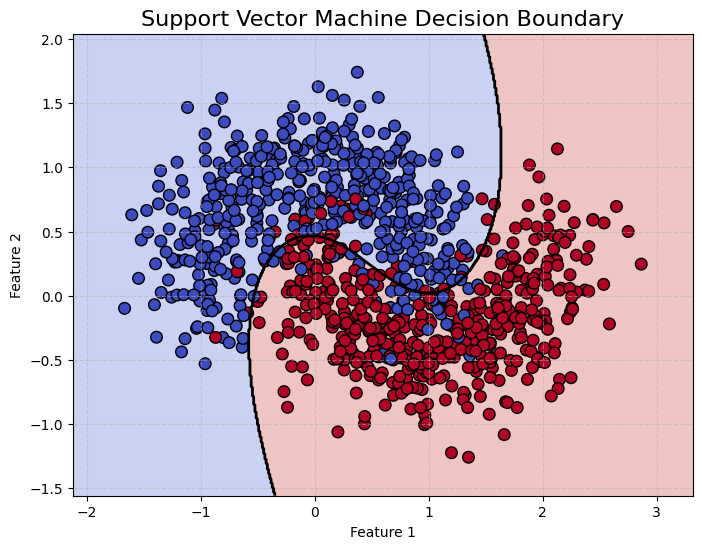


Accuracy: 91.80%


In [44]:
from models.support_vector_machine_class import SVM

svm_moons = SVM(sigma=1)
svm_moons.fit(X_moons, Y_moons, C=2.0, tol=10e-3, max_passes=10)
plot_decision_boundary(svm_moons, X_moons, Y_moons, figsize=(8, 6), resolution=500)
moons_pred = svm_moons.predict(X_moons, Y_moons, X_moons)

# Once again, changing our Y values to live in {0, 1}
Y_moons[Y_moons==-1] = 0

print(f"\nAccuracy: {np.mean(moons_pred==Y_moons)*100:.2f}%")

###Neural Network on Moons
Finally, we will implement our neural network on the `make_moons` dataset and analyze its performance as we have done previously.

Through experimentation, I found these hyperparameters to converge well on this dataset:
* epochs = 5000
* lr = 2.5
* update_lr = True

epoch: 0: Loss; 0.686482916151951, Training Accuracy; 0.644
epoch: 250: Loss; 0.3424919167086335, Training Accuracy; 0.852
epoch: 500: Loss; 0.3365561567496304, Training Accuracy; 0.852
epoch: 750: Loss; 0.2907195319318425, Training Accuracy; 0.875
epoch: 1000: Loss; 0.25817522399314624, Training Accuracy; 0.89
epoch: 1250: Loss; 0.21753860929392982, Training Accuracy; 0.915
epoch: 1500: Loss; 0.21378565760096768, Training Accuracy; 0.914
epoch: 1750: Loss; 0.2117769804121338, Training Accuracy; 0.909
epoch: 2000: Loss; 0.2103486815816278, Training Accuracy; 0.911
epoch: 2250: Loss; 0.20972361326595798, Training Accuracy; 0.911
epoch: 2500: Loss; 0.20913035154876702, Training Accuracy; 0.911
epoch: 2750: Loss; 0.2085594859447043, Training Accuracy; 0.91
epoch: 3000: Loss; 0.20800597877053656, Training Accuracy; 0.908
epoch: 3250: Loss; 0.20773485735230998, Training Accuracy; 0.908
epoch: 3500: Loss; 0.20746721172272106, Training Accuracy; 0.911
epoch: 3750: Loss; 0.20720291404834776, T

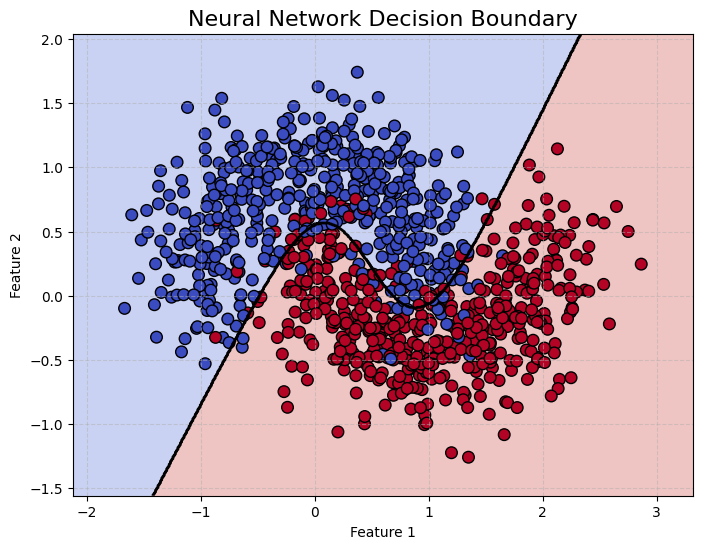


Accuracy: 91.30%


In [43]:
from models.neural_network_class import NeuralNetwork

nn_moons = NeuralNetwork()
# Our neural network expects us to transpose our data to fit the (n, m) shape convention
nn_moons.fit(X_moons.T, Y_moons.T, epochs=5000, lr=2.5, update_lr=True)
plot_decision_boundary(nn_moons, X_moons, Y_moons, figsize=(8, 6), resolution=500)
print(f"\nAccuracy: {np.mean(nn_moons.predict(X_moons.T) == Y_moons)*100:.2f}%")

###Moons Summary
Overall, we see a similar pattern to that of the circles dataset, where the support vector machine and neural network perform much better than the logistic regression classifier. In this dataset, the logistic regression classifier was able to achieve an 85% accuracy due to the structure of the curves, however, the support vector machine and neural network achieve above a 91% accuracy by following the curves.

Let's move onto our final dataset, `make_circles`.

##Make_Circles

In this section, we will go through our final dataset, being scikit-learn's `make_circles` dataset. We will again implement our logistic regression classifier, support vector machine, and neural network.

Let's create the dataset and visualize it.

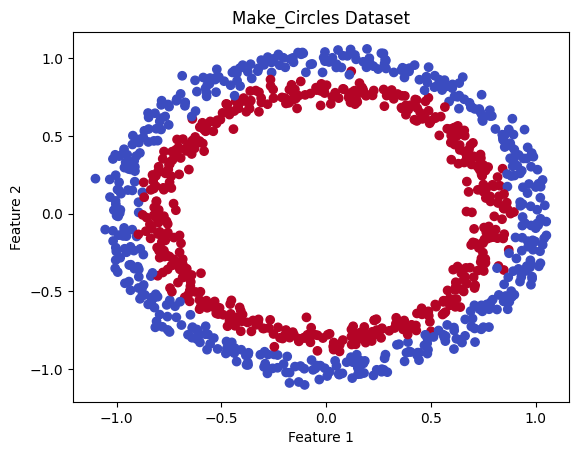

In [18]:
X_circles, Y_circles = make_circles(n_samples=1000,
    noise=0.045,
    random_state=42,)

plt.figure(figsize=(6.4, 4.8))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=Y_circles, cmap=plt.cm.coolwarm)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make_Circles Dataset")
plt.show();

###Logistic Regression on Circles
Now, we will implement our logistic regression classifier on this dataset. Note that logistic regression produces a linear decision boundary, meaning we cannot expect an accurate fit.

Through experimentation, I found these hyperparameters to converge well on this dataset:
* eps = 10e-5
* lr = 0.01

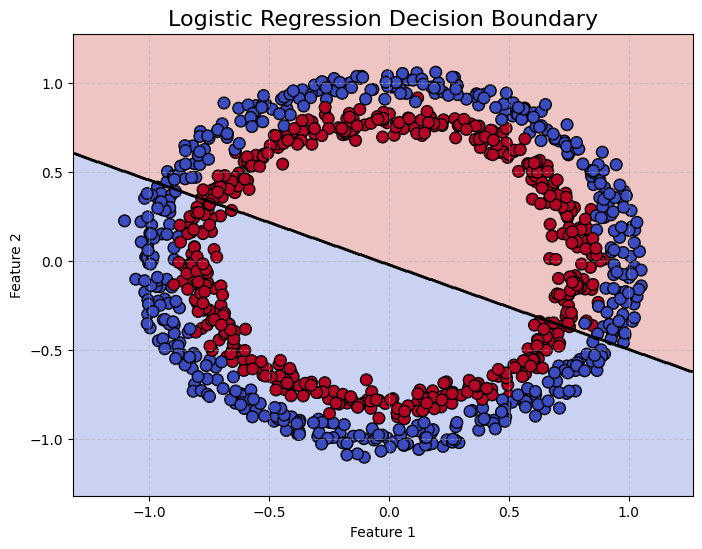


Accuracy: 50.10%


In [34]:
from models.logistic_regression_class import Logistic_Regression

lr_circles = Logistic_Regression(eps=10e-5)
lr_circles.fit(X_circles, Y_circles, lr=0.01)
plot_decision_boundary(lr_circles, X_circles, Y_circles, figsize=(8, 6), resolution=500)
print(f"\nAccuracy: {np.mean(lr_circles.predict(X_circles)==Y_circles)*100:.2f}%")

###Support Vector Machine on Circles
Again, we will implement our support vector machine and analyze it's performace, this time on the `make_circles` dataset.

Through experimentation, I found these hyperparameters to converge well on this dataset:
* sigma = 1
* C = 1.0
* tol = 1e-3
* max_passes = 10

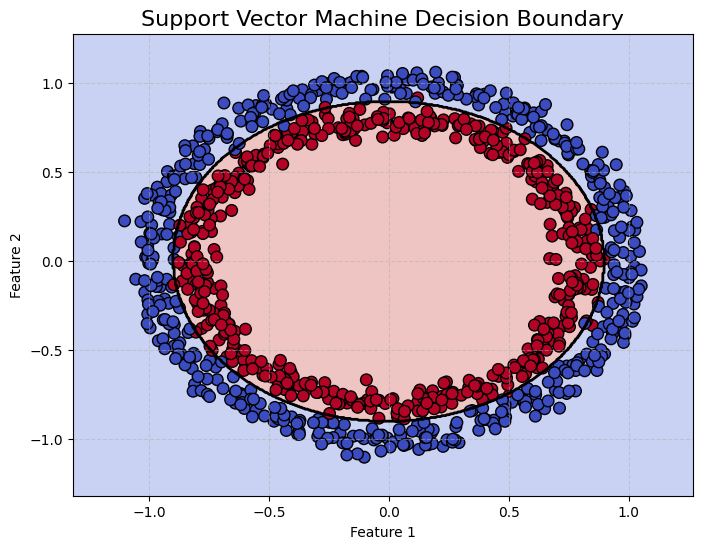


Accuracy: 98.5%


In [36]:
from models.support_vector_machine_class import SVM

svm_circles = SVM(sigma=1)
svm_circles.fit(X_circles, Y_circles, C=1.0, tol=1e-3, max_passes=10)
plot_decision_boundary(svm_circles, X_circles, Y_circles,figsize=(8,6), resolution=500)
circles_pred = svm_circles.predict(X_circles, Y_circles, X_circles)

#Again, our support vector machine changes Y to live in {-1, 1}, so we need to reverse that back to {0, 1}
Y_circles[Y_circles==-1] = 0

print(f"\nAccuracy: {np.mean(circles_pred==Y_circles)*100}%")

###Neural Network on Circles
finally, we will implement our neural network on the `make_circles` dataset, again analyzing it with a decision boundary plot and the accuracy.

Through experimentation, I found these hyperparameters to converge well on this dataset:
* epochs = 20000
* lr = 5
* update_lr = True

epoch: 0: Loss; 0.7178007620633182, Training Accuracy; 0.5
epoch: 1000: Loss; 0.6931391757598736, Training Accuracy; 0.497
epoch: 2000: Loss; 0.6930723556655165, Training Accuracy; 0.502
epoch: 3000: Loss; 0.6829978204652696, Training Accuracy; 0.636
epoch: 4000: Loss; 0.5190174894641738, Training Accuracy; 0.681
epoch: 5000: Loss; 0.6936571844025511, Training Accuracy; 0.612
epoch: 6000: Loss; 0.5286312850738664, Training Accuracy; 0.683
epoch: 7000: Loss; 0.29366479969626663, Training Accuracy; 0.844
epoch: 8000: Loss; 0.4220094482002355, Training Accuracy; 0.818
epoch: 9000: Loss; 0.08729658594980046, Training Accuracy; 0.982
epoch: 10000: Loss; 0.09266902063977563, Training Accuracy; 0.982
epoch: 11000: Loss; 0.0774139604336738, Training Accuracy; 0.984
epoch: 12000: Loss; 0.10860110882769335, Training Accuracy; 0.982
epoch: 13000: Loss; 0.05489795090263562, Training Accuracy; 0.987
epoch: 14000: Loss; 0.04614546154189799, Training Accuracy; 0.987
epoch: 15000: Loss; 0.042354420904

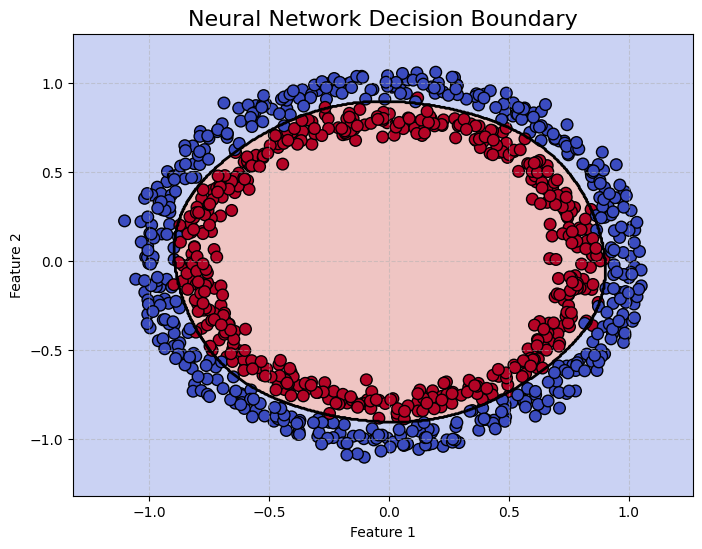


Accuracy: 0.988


In [24]:
from models.neural_network_class import NeuralNetwork

nn_circles = NeuralNetwork()
# Our neural network expects us to transpose our data to fit the (n, m) shape convention
nn_circles.fit(X_circles.T, Y_circles.T, epochs=20000, lr=5, update_lr=True)
plot_decision_boundary(nn_circles, X_circles, Y_circles, figsize=(8, 6), resolution=500)
print(f"\nAccuracy: {np.mean(nn_circles.predict(X_circles.T)==Y_circles)}")

###Circles Summary
As expected, the logistic regression classifier performed poorly since it was restricted to making a linear decision boundary, meaning it wasn't much better than a random guess. The support vector machine and the neural network fit this dataset well as they could construct a circular decision boundary, both achieving above a 98% accuracy.


##Conclusion
In conclusion, we can see the power of non-linear models as we can fit data that is inherently non-linear much better than simpler linear models can; however, when the data is linear or has linear attributes, linear models can outperform their non-linear counterparts. This can be seen when the logistic regression model performed really well on `make_blobs` and decently well on `make_moons`, but was outperformed by the support vector machine and neural network on `make_moons` and `make_circles`. Hyperparameters were chosen via brief experimentation, especially with the neural network. To conclude, these experiments display the performance of three models on various datasets with differing geometric structures, showcasing the implementation of classical models from scratch.